# Stage 04 — Experiment Design & Validation

Experiment validation precedes treatment-effect inference: allocation and observable baseline characteristics must be credible before interpreting outcome differences. Randomization validation is distinct from outcome testing. Stage 03 found descriptive outcome differences but made no inferential conclusions. This notebook establishes the Stage 05 framework and performs only allocation and baseline-balance diagnostics.

## 1. Load the analysis-ready dataset

The processed dataset is read only. Hashes confirm that neither the raw nor processed dataset changes during execution.

In [1]:
from hashlib import sha256
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chisquare

from src.statistical_tests import (
    binary_standardized_mean_difference,
    continuous_standardized_mean_difference,
)

project_root = Path('.')
if not (project_root / 'data/processed/Hillstrom_clean.csv').exists():
    project_root = Path('..')
raw_path = project_root / 'data/raw/Hillstrom.csv'
processed_path = project_root / 'data/processed/Hillstrom_clean.csv'
figure_dir = project_root / 'outputs/figures'
table_dir = project_root / 'outputs/tables'
control_group = 'No E-Mail'
treatment_groups = ['Mens E-Mail', 'Womens E-Mail']
group_order = [control_group, *treatment_groups]

def file_sha256(path):
    return sha256(path.read_bytes()).hexdigest()

raw_hash_before = file_sha256(raw_path)
processed_hash_before = file_sha256(processed_path)
data = pd.read_csv(processed_path)
print('Analysis population: {:,} observations × {} columns'.format(len(data), data.shape[1]))

Analysis population: 64,000 observations × 12 columns


## 2. Formal experiment definition

Verified from the dataset: segment contains No E-Mail, Mens E-Mail, and Womens E-Mail. The project framework treats each row as a likely individual customer or recipient; segment as treatment assignment; No E-Mail as the natural control; and the two email-labelled arms as treatments. Individual-unit status, assignment mechanism, exposure timing, and email content cannot be verified from the CSV.

## 3. Analysis population

All 64,000 observations are retained. Stage 02 found no missing values, invalid outcomes, or defensible reason for removal. Exact duplicate rows are retained because no customer identifier exists and identical records do not establish repeated experimental units. The intended analysis is as close to intention-to-treat as possible: analyze each row by recorded segment. The lack of identifiers prevents verifying unique experimental units.

## 4. Outcome metrics and metric hierarchy

The available outcomes are visit, conversion, and spend. Visit and conversion are observed binary 0/1 variables, tentatively interpreted as visit and purchase indicators; their definitions and windows are unknown. Spend is a non-negative continuous measure that is approximately 99% zero and strongly right-skewed among positive values.

This project pre-specifies mean spend per assigned experimental unit as the primary business metric because it is closest to direct economic impact. Conversion rate and visit rate are secondary metrics. This is the project's analysis framework, not a claim about the original pre-registered primary endpoint, which cannot be verified from the CSV.

In [2]:
outcome_framework = pd.DataFrame([
    ['visit', 'int64, observed 0/1', 'Likely visit indicator', 'Binary probability', 'Sparse outcome; definition and window unknown'],
    ['conversion', 'int64, observed 0/1', 'Likely conversion indicator', 'Binary probability', 'Very sparse outcome; definition and window unknown'],
    ['spend', 'float64, non-negative', 'Likely spend or revenue', 'Mean spend per assigned unit', 'Extreme zero inflation and right skew'],
], columns=['Metric', 'Observed type', 'Tentative interpretation', 'Scale', 'Analytical challenge'])
display(outcome_framework)

,Metric,Observed type,Tentative interpretation,Scale,Analytical challenge
0,visit,"int64, observed 0/1",Likely visit indicator,Binary probability,Sparse outcome; definition and window unknown
1,conversion,"int64, observed 0/1",Likely conversion indicator,Binary probability,Very sparse outcome; definition and window unk...
2,spend,"float64, non-negative",Likely spend or revenue,Mean spend per assigned unit,Extreme zero inflation and right skew


## 5. Estimands and pre-specified Stage 05 hypotheses

Primary comparisons are Mens E-Mail versus No E-Mail and Womens E-Mail versus No E-Mail. Mens E-Mail versus Womens E-Mail is not primary and would be labelled secondary if reported. For each treatment-control comparison, Stage 05 estimands are the difference in mean spend per assigned unit, difference in conversion probability, and difference in visit probability. Relative lift may be supplementary.

For each treatment-control pair and each outcome, H0 states equality between assigned groups and H1 states a difference. Tests will be two-sided because no evidence of pre-specified directional hypotheses is available. These hypotheses are not executed here.

## 6. Significance and multiple testing

Stage 05 will use alpha = 0.05 and 95% confidence intervals. Alpha controls a long-run false-positive rate under the testing procedure; it is not the probability that a null hypothesis is true. The two primary treatment-versus-control spend comparisons will use Holm adjustment. Holm controls family-wise error while being less conservative than applying a single Bonferroni threshold to all tests. Conversion and visit are secondary; their two treatment-control comparisons will be clearly labelled and Holm-adjusted within each outcome family.

## 7. Sample ratio mismatch diagnostic

Original randomization documentation is unavailable. This diagnostic therefore assumes that the near-equal three-arm design implies expected equal allocation (one-third per arm). H0: observed assignment proportions are consistent with equal allocation. H1: they differ. This is an SRM diagnostic, not an outcome or treatment-effect test.

In [3]:
observed_counts = data['segment'].value_counts().reindex(group_order)
expected_counts = pd.Series(len(data) / 3, index=group_order)
srm_result = chisquare(observed_counts, f_exp=expected_counts)
srm_summary = pd.DataFrame({'Treatment Group': group_order, 'Observed Count': observed_counts.to_numpy(), 'Expected Count': expected_counts.to_numpy(), 'Observed Percentage': (observed_counts / len(data) * 100).to_numpy(), 'Expected Percentage': [100 / 3] * 3})
display(srm_summary.round(2))
print('Chi-square statistic: {:.4f}'.format(srm_result.statistic))
print('Degrees of freedom: 2')
print('p-value: {:.4f}'.format(srm_result.pvalue))
print('SRM conclusion:', 'No evidence against assumed equal allocation.' if srm_result.pvalue >= 0.05 else 'Evidence against assumed equal allocation.')

,Treatment Group,Observed Count,Expected Count,Observed Percentage,Expected Percentage
0,No E-Mail,21306,21333.33,33.29,33.33
1,Mens E-Mail,21307,21333.33,33.29,33.33
2,Womens E-Mail,21387,21333.33,33.42,33.33


Chi-square statistic: 0.2025
Degrees of freedom: 2
p-value: 0.9037
SRM conclusion: No evidence against assumed equal allocation.


## 8. Observable baseline balance

Only likely pre-treatment/customer characteristics are assessed: recency, history, history_segment, mens, womens, zip_code, newbie, and channel. Outcomes are excluded. Standardized mean differences (SMDs) quantify the magnitude of treatment-versus-control differences. Continuous-variable SMDs use pooled standard deviations; binary variables and category levels use pooled Bernoulli standard deviations. Absolute SMD below 0.10 is a commonly used small-imbalance heuristic, not proof of successful randomization.

In [4]:
continuous_covariates = ['recency', 'history']
binary_covariates = ['mens', 'womens', 'newbie']
categorical_covariates = ['history_segment', 'zip_code', 'channel']

continuous_summary = data.groupby('segment', observed=True)[continuous_covariates].agg(['count', 'mean', 'std', 'median']).reindex(group_order)
display(continuous_summary.round(2))
for covariate in categorical_covariates:
    print('\n{}: percentage within treatment group'.format(covariate))
    display(pd.crosstab(data[covariate], data['segment'], normalize='columns').reindex(columns=group_order).mul(100).round(2))

recency                    history                        
                count  mean   std median   count    mean     std  median
segment                                                                 
No E-Mail       21306  5.75  3.50    5.0   21306  240.88  252.74  156.66
Mens E-Mail     21307  5.77  3.51    6.0   21307  242.84  260.36  157.22
Womens E-Mail   21387  5.77  3.51    6.0   21387  242.54  255.33  160.09


history_segment: percentage within treatment group


segment,No E-Mail,Mens E-Mail,Womens E-Mail
history_segment,,,
1) $0 - $100,35.73,36.25,35.69
2) $100 - $200,22.70,22.02,22.10
3) $200 - $350,18.98,19.20,19.43
4) $350 - $500,9.97,9.84,10.23
5) $500 - $750,7.75,7.50,7.77
"6) $750 - $1,000",2.92,3.02,2.77
"7) $1,000 +",1.95,2.18,2.00



zip_code: percentage within treatment group


segment,No E-Mail,Mens E-Mail,Womens E-Mail
zip_code,,,
Rural,14.73,15.22,14.87
Surburban,45.18,44.59,45.12
Urban,40.09,40.19,40.01



channel: percentage within treatment group


segment,No E-Mail,Mens E-Mail,Womens E-Mail
channel,,,
Multichannel,12.23,12.09,12.06
Phone,43.78,43.37,44.20
Web,43.99,44.54,43.74


In [5]:
control_data = data.loc[data['segment'] == control_group]
balance_rows = []
for treatment_group in treatment_groups:
    treatment_data = data.loc[data['segment'] == treatment_group]
    comparison = '{} vs {}'.format(treatment_group, control_group)
    for covariate in continuous_covariates:
        balance_rows.append([comparison, covariate, 'continuous', treatment_data[covariate].mean(), control_data[covariate].mean(), continuous_standardized_mean_difference(treatment_data[covariate], control_data[covariate])])
    for covariate in binary_covariates:
        balance_rows.append([comparison, covariate, 'binary', treatment_data[covariate].mean(), control_data[covariate].mean(), binary_standardized_mean_difference(treatment_data[covariate], control_data[covariate])])
    for covariate in categorical_covariates:
        for level in sorted(data[covariate].unique()):
            treatment_indicator = (treatment_data[covariate] == level).astype(int)
            control_indicator = (control_data[covariate] == level).astype(int)
            balance_rows.append([comparison, '{}: {}'.format(covariate, level), 'categorical level', treatment_indicator.mean(), control_indicator.mean(), binary_standardized_mean_difference(treatment_indicator, control_indicator)])

baseline_balance_summary = pd.DataFrame(balance_rows, columns=['Comparison', 'Covariate', 'Covariate Type', 'Treatment Value/Proportion', 'Control Value/Proportion', 'SMD'])
baseline_balance_summary['Absolute SMD'] = baseline_balance_summary['SMD'].abs()
baseline_balance_summary['Heuristic Assessment'] = np.where(baseline_balance_summary['Absolute SMD'] < 0.10, 'Below 0.10 heuristic', 'At or above 0.10 heuristic')
baseline_balance_summary = baseline_balance_summary.sort_values(['Absolute SMD', 'Comparison'], ascending=[False, True]).reset_index(drop=True)
display(baseline_balance_summary.round(4))
largest_balance_row = baseline_balance_summary.iloc[0]
print('Largest absolute SMD: {:.4f} for {} ({})'.format(largest_balance_row['Absolute SMD'], largest_balance_row['Covariate'], largest_balance_row['Comparison']))

,Comparison,Covariate,Covariate Type,Treatment Value/Proportion,Control Value/Proportion,SMD,Absolute SMD,Heuristic Assessment
0,Mens E-Mail vs No E-Mail,history_segment: 2) $100 - $200,categorical level,0.2202,0.2270,-0.0164,0.0164,Below 0.10 heuristic
1,Mens E-Mail vs No E-Mail,"history_segment: 7) $1,000 +",categorical level,0.0218,0.0195,0.0158,0.0158,Below 0.10 heuristic
2,Womens E-Mail vs No E-Mail,history_segment: 2) $100 - $200,categorical level,0.2210,0.2270,-0.0143,0.0143,Below 0.10 heuristic
3,Mens E-Mail vs No E-Mail,zip_code: Rural,categorical level,0.1522,0.1473,0.0137,0.0137,Below 0.10 heuristic
4,Mens E-Mail vs No E-Mail,zip_code: Surburban,categorical level,0.4459,0.4518,-0.0117,0.0117,Below 0.10 heuristic
5,Womens E-Mail vs No E-Mail,history_segment: 3) $200 - $350,categorical level,0.1943,0.1898,0.0114,0.0114,Below 0.10 heuristic
6,Mens E-Mail vs No E-Mail,channel: Web,categorical level,0.4454,0.4399,0.0110,0.0110,Below 0.10 heuristic
7,Mens E-Mail vs No E-Mail,history_segment: 1) $0 - $100,categorical level,0.3625,0.3573,0.0109,0.0109,Below 0.10 heuristic
8,Mens E-Mail vs No E-Mail,history_segment: 5) $500 - $750,categorical level,0.0750,0.0775,-0.0097,0.0097,Below 0.10 heuristic
9,Womens E-Mail vs No E-Mail,"history_segment: 6) $750 - $1,000",categorical level,0.0277,0.0292,-0.0088,0.0088,Below 0.10 heuristic


Largest absolute SMD: 0.0164 for history_segment: 2) $100 - $200 (Mens E-Mail vs No E-Mail)


## 9. Baseline balance visualization

This Love-plot-style display shows absolute SMDs for each treatment-versus-control comparison. The reference line at 0.10 is a heuristic, not a pass/fail threshold.

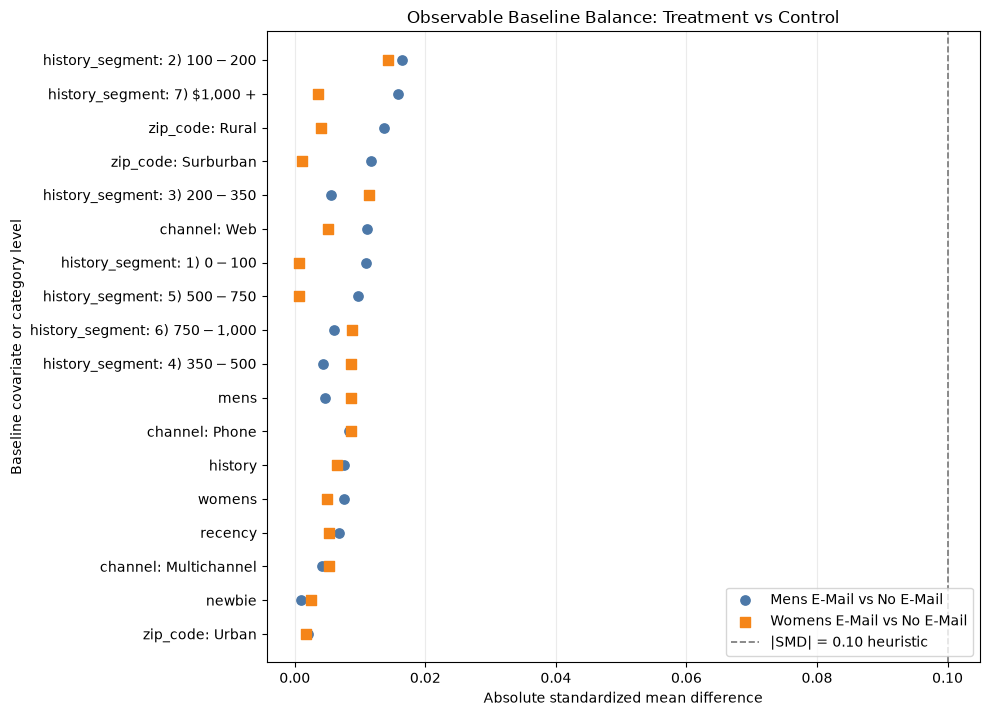

In [6]:
plot_data = baseline_balance_summary.pivot(index='Covariate', columns='Comparison', values='Absolute SMD').fillna(0)
plot_data = plot_data.loc[plot_data.max(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(10, max(6, 0.32 * len(plot_data) + 1.5)))
y_positions = np.arange(len(plot_data))
for comparison, color, marker in zip(plot_data.columns, ['#4C78A8', '#F58518'], ['o', 's']):
    ax.scatter(plot_data[comparison], y_positions, label=comparison, color=color, marker=marker, s=45, zorder=3)
ax.axvline(0.10, color='#777777', linestyle='--', linewidth=1.2, label='|SMD| = 0.10 heuristic')
ax.set_yticks(y_positions, plot_data.index)
ax.set_xlabel('Absolute standardized mean difference')
ax.set_ylabel('Baseline covariate or category level')
ax.set_title('Observable Baseline Balance: Treatment vs Control')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
fig.savefig(figure_dir / 'baseline_balance_smd.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Experiment-integrity checklist

This checklist distinguishes observed checks from limitations that cannot be resolved without external experiment documentation.

In [7]:
integrity_checklist = pd.DataFrame([
    ['Treatment allocation', 'Three observed arms with near-equal counts', 'Consistent with a three-arm design', 'Original allocation protocol unavailable'],
    ['SRM', 'chi-square = {:.4f}, p = {:.4f}'.format(srm_result.statistic, srm_result.pvalue), 'No evidence against assumed equal allocation at alpha = 0.05', 'Equal allocation is inferred, not documented'],
    ['Missing data', 'No missing cells', 'No missing-data handling required', 'Dataset documentation remains incomplete'],
    ['Outcome validity', 'Stage 02 found zero specified logical conflicts', 'Observed coding is internally consistent', 'Definitions and measurement window unknown'],
    ['Duplicate experimental units', '6,562 exact duplicate rows retained', 'No defensible removal without identifier', 'Unique customer status cannot be verified'],
    ['Baseline balance', 'Largest |SMD| = {:.4f}'.format(largest_balance_row['Absolute SMD']), 'Observed differences are small under the 0.10 heuristic', 'Observable data cannot prove randomization validity'],
    ['Treatment-label validity', 'Three non-missing observed labels', 'Labels internally consistent', 'Assignment and exposure cannot be externally verified'],
    ['Temporal monitoring', 'No timestamp variable', 'Not assessable', 'Cannot check trends or time anomalies'],
    ['Outcome-window documentation', 'No window metadata', 'Not assessable', 'Cannot verify timing or attribution period'],
], columns=['Check', 'Result', 'Interpretation', 'Limitation'])
display(integrity_checklist)

,Check,Result,Interpretation,Limitation
0,Treatment allocation,Three observed arms with near-equal counts,Consistent with a three-arm design,Original allocation protocol unavailable
1,SRM,"chi-square = 0.2025, p = 0.9037",No evidence against assumed equal allocation a...,"Equal allocation is inferred, not documented"
2,Missing data,No missing cells,No missing-data handling required,Dataset documentation remains incomplete
3,Outcome validity,Stage 02 found zero specified logical conflicts,Observed coding is internally consistent,Definitions and measurement window unknown
4,Duplicate experimental units,"6,562 exact duplicate rows retained",No defensible removal without identifier,Unique customer status cannot be verified
5,Baseline balance,Largest |SMD| = 0.0164,Observed differences are small under the 0.10 ...,Observable data cannot prove randomization val...
6,Treatment-label validity,Three non-missing observed labels,Labels internally consistent,Assignment and exposure cannot be externally v...
7,Temporal monitoring,No timestamp variable,Not assessable,Cannot check trends or time anomalies
8,Outcome-window documentation,No window metadata,Not assessable,Cannot verify timing or attribution period


## 11. Stage 05 statistical method, sensitivity, and segmentation plans

For binary visit and conversion, Stage 05 will use two-sample proportion inference for each treatment-control comparison and report group rates, absolute risk difference, relative lift, 95% confidence interval, p-value, and documented Holm-adjusted p-value. For primary spend, the estimand remains mean spend per assigned unit. Planned robust inference is a nonparametric bootstrap confidence interval; permutation inference may be considered if justified; and conventional mean-difference inference is a reference/sensitivity analysis. The mean is retained because all-group medians are expected to be zero and do not represent expected revenue per assigned unit.

Sensitivity work may include bootstrap inference, conventional mean inference, positive-spend probability, conditional purchaser spend as descriptive decomposition, baseline-covariate regression adjustment, and sensitivity to extreme spend. Extreme spend will not be removed or winsorized in the primary analysis. Potential exploratory segmentation dimensions are channel, zip_code, newbie, history_segment, mens, and womens. Any subgroup effects are deferred to Stage 07, are exploratory unless externally pre-specified, and carry multiple-comparison and false-positive risks.

## 12. Validation limitations

The dataset lacks a unique customer identifier, experiment timestamp, documented randomization ratio, outcome measurement window, original pre-registered hypotheses, original primary endpoint, and complete definitions/timing for several customer characteristics. These gaps constrain verification of unique-unit assignment, exposure delivery, protocol adherence, timing, and the original study plan.

## 13. Stage 04 validation summary

In [8]:
validation_summary = pd.DataFrame([
    ['Experimental unit', 'Likely individual customer/recipient; unverified without identifier'],
    ['Control', control_group],
    ['Treatments', '; '.join(treatment_groups)],
    ['Primary project metric', 'Mean spend per assigned experimental unit'],
    ['Secondary metrics', 'Conversion rate; visit rate'],
    ['Primary comparisons', 'Mens E-Mail vs No E-Mail; Womens E-Mail vs No E-Mail'],
    ['Alpha and confidence', '0.05; 95%'],
    ['Multiplicity strategy', 'Holm for primary spend comparisons and within each secondary outcome family'],
    ['SRM result', 'chi-square = {:.4f}, df = 2, p = {:.4f}; no evidence against assumed allocation'.format(srm_result.statistic, srm_result.pvalue)],
    ['Baseline balance', 'Largest |SMD| = {:.4f}; all observed SMDs below the 0.10 heuristic'.format(largest_balance_row['Absolute SMD'])],
    ['Major limitations', 'No identifier, timestamp, documented allocation ratio, outcome window, or original pre-registration'],
], columns=['Framework Element', 'Pre-specified Decision / Finding'])
display(validation_summary)
validation_summary.to_csv(table_dir / 'experiment_validation_summary.csv', index=False)
baseline_balance_summary.to_csv(table_dir / 'baseline_balance_summary.csv', index=False)
print('Saved experiment-validation and baseline-balance summary tables.')

,Framework Element,Pre-specified Decision / Finding
0,Experimental unit,Likely individual customer/recipient; unverifi...
1,Control,No E-Mail
2,Treatments,Mens E-Mail; Womens E-Mail
3,Primary project metric,Mean spend per assigned experimental unit
4,Secondary metrics,Conversion rate; visit rate
5,Primary comparisons,Mens E-Mail vs No E-Mail; Womens E-Mail vs No ...
6,Alpha and confidence,0.05; 95%
7,Multiplicity strategy,Holm for primary spend comparisons and within ...
8,SRM result,"chi-square = 0.2025, df = 2, p = 0.9037; no ev..."
9,Baseline balance,Largest |SMD| = 0.0164; all observed SMDs belo...


Saved experiment-validation and baseline-balance summary tables.


## Stage 04 Findings

Under the explicitly assumed equal-allocation design, the SRM diagnostic does not provide evidence of sample ratio mismatch. Observable baseline characteristics have small treatment-versus-control differences: all calculated absolute SMDs fall below the 0.10 heuristic. This supports, but does not prove, acceptable observable balance.

No observed data-integrity issue prevents proceeding to treatment-effect analysis: missingness is absent, specified outcome-logic checks were clean, and duplicate rows lack evidence sufficient for removal. What remains unvalidated includes unique-unit status, actual randomization ratio, exposure timing, outcome window, protocol adherence, original primary endpoint, and original hypotheses.

Stage 05 is pre-specified to use mean spend per assigned unit as the primary metric; conversion and visit as secondary metrics; Mens-versus-control and Womens-versus-control as primary comparisons; two-sided alpha = 0.05 inference with 95% intervals; and Holm multiplicity adjustment. Spend inference will be bootstrap-focused with conventional mean-based analysis as sensitivity/reference. No treatment-effect estimate, winning treatment, or business recommendation appears here.

## 14. File-integrity confirmation

In [9]:
raw_hash_after = file_sha256(raw_path)
processed_hash_after = file_sha256(processed_path)
print('Raw dataset unchanged during notebook execution:', raw_hash_before == raw_hash_after)
print('Processed dataset unchanged during notebook execution:', processed_hash_before == processed_hash_after)
print('Treatment-effect tests executed in this notebook: none')

Raw dataset unchanged during notebook execution: True
Processed dataset unchanged during notebook execution: True
Treatment-effect tests executed in this notebook: none
